In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
d = pd.read_csv("car_fuel_efficiency_2026.csv")[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]]
d

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


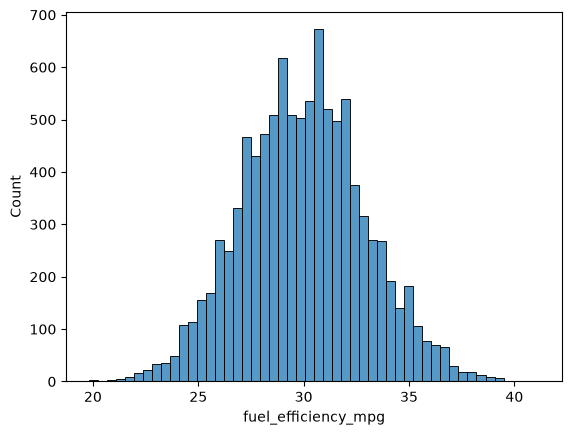

In [125]:
sns.histplot(d['fuel_efficiency_mpg'], bins=50)
plt.show()

In [126]:
d.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [127]:
x = sorted(d['horsepower'].dropna())
n = len(x)
(x[n // 2] + x[(n // 2) - 1]) / 2

254.0

In [128]:
d.head(7)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
5,2290,266.0,4260,2007,31.2
6,2270,250.0,4310,1992,26.8


In [129]:
d.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [130]:
n = len(d)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n) # evenly spaced values
np.random.shuffle(idx)

d_train = d.iloc[idx[:n_train]]
d_val = d.iloc[idx[n_train:n_train + n_val]]
d_test = d.iloc[idx[n_train+n_val:]]

len(d_train), len(d_val), len(d_test)

(6000, 2000, 2000)

In [131]:
d_train.drop('fuel_efficiency_mpg', axis=1).isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [132]:
d_train['fuel_efficiency_mpg'].values

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [99]:
d_val.shape

(2000, 5)

In [150]:
def rmse(y_val, y_pred):
    return np.sqrt(np.mean((y_val - y_pred)**2))

In [151]:
def train_linear_regression(X,y,r=0.0):
    bias = np.ones(X.shape[0])
    X = np.column_stack([bias, X])
    w = np.linalg.inv(X.T @ X + r * np.eye(X.shape[1])) @ X.T @ y  # beta = (X^TX)^-1 X^T y
    return w[0], w[1:]    # w[0] = bias, w[1:] = feature weights

X_train = d_train.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
y_train = d_train['fuel_efficiency_mpg'].values

X_val = d_val.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
y_val = d_val['fuel_efficiency_mpg'].values

# train
w0, w = train_linear_regression(X_train, y_train)

# pred
y_pred = w0 + X_val @ w
rmse_zero = rmse(y_val, y_pred)
round(rmse_zero, 3)

np.float64(2.205)

In [152]:
hp_mean = d_train['horsepower'].mean()

X_train = d_train.drop('fuel_efficiency_mpg', axis=1).fillna(hp_mean).values
X_val = d_val.drop('fuel_efficiency_mpg', axis=1).fillna(hp_mean).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_val @ w # yhat = b0 + XB
rmse_mean = rmse(y_val, y_pred)
round(rmse_mean, 3)

np.float64(2.202)

In [153]:
r_vals = [0, 0.01, 0.1, 1, 5, 10, 100]

X_train = d_train.drop('fuel_efficiency_mpg', axis=1).fillna(hp_mean).values
X_val = d_val.drop('fuel_efficiency_mpg', axis=1).fillna(hp_mean).values

y_train = d_train['fuel_efficiency_mpg'].values
y_val = d_val['fuel_efficiency_mpg'].values

for r in r_vals:
    w0, w = train_linear_regression(X_train, y_train, r)
    y_pred = w0 + X_val @ w
    print(f"r={r}, rmse={round(rmse(y_val, y_pred), 4)}")

r=0, rmse=2.2018
r=0.01, rmse=2.2018
r=0.1, rmse=2.2156
r=1, rmse=2.3442
r=5, rmse=2.4145
r=10, rmse=2.4268
r=100, rmse=2.4386


In [157]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

n = d.shape[0]

# train/val/test - 60/20/20
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_totals = []

for seed in seeds:
    np.random.seed(seed)

    # random sequence of indices
    idx = np.arange(n)
    np.random.shuffle(idx)

    # subsetting data into train/test/val splits (60/20/20)
    train = d.iloc[idx[:n_train]]
    val = d.iloc[idx[n_train:n_train+n_val]]
    test = d.iloc[idx[n_train+n_val:]]

    # imputing
    X_train = train.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
    y_train = train['fuel_efficiency_mpg'].values

    w0, w = train_linear_regression(X_train, y_train)
    X_val = val.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
    y_val = val['fuel_efficiency_mpg'].values
    
    y_pred = w0 + X_val @ w 
    rmse_totals.append(rmse(y_val, y_pred))

print(round(np.std(rmse_totals), 3))

0.029


In [166]:
np.random.seed(9)
n = d.shape[0]
idx = np.arange(n)
np.random.shuffle(idx)

n_train = int(.6 * n)
n_val = int(.2 * n)
n_test = int(.2 * n)

train = d.iloc[idx[:n_train]]
val = d.iloc[idx[n_train:n_train+n_val]]
test = d.iloc[idx[n_train+n_val:]]

train_val = pd.concat([train, val])

X_train = train_val.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
y_train = train_val['fuel_efficiency_mpg'].values

X_test = test.drop('fuel_efficiency_mpg', axis=1).fillna(0).values
y_test = test['fuel_efficiency_mpg'].values

w0, w = train_linear_regression(X_train, y_train, r=0.001)

y_pred = w0 + X_test @ w
rmse(y_pred, y_test)

np.float64(2.2358277471945915)